In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as mat

In [3]:
test_data = pd.read_csv("test.csv")
train_data = pd.read_csv("train.csv")
sample_sub = pd.read_csv("sample_submission.csv")

In [4]:
test_data.head()

,row_id,datetime
0,94993,2019-01-01 00:00:00
1,94994,2019-01-01 01:00:00
2,94995,2019-01-01 02:00:00
3,94996,2019-01-01 03:00:00
4,94997,2019-01-01 04:00:00


In [5]:
train_data.head()

,row_id,datetime,energy
0,1,2008-03-01 00:00:00,1259.985563
1,2,2008-03-01 01:00:00,1095.541500
2,3,2008-03-01 02:00:00,1056.247500
3,4,2008-03-01 03:00:00,1034.742000
4,5,2008-03-01 04:00:00,1026.334500


In [6]:
sample_sub.head()

,row_id,energy
0,94993,1702.995014
1,94994,1702.995014
2,94995,1702.995014
3,94996,1702.995014
4,94997,1702.995014


In [7]:
test_data.info()
train_data.info()
sample_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   row_id    26304 non-null  int64 
 1   datetime  26304 non-null  object
dtypes: int64(1), object(1)
memory usage: 411.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94992 entries, 0 to 94991
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   row_id    94992 non-null  int64  
 1   datetime  94992 non-null  object 
 2   energy    93092 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   row_id  26304 non-null  int64  
 1   energy  26304 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 411.1 KB


In [7]:
#train_data.head()

In [9]:
new_train_data = train_data[train_data['energy'].notna()]

In [10]:
new_train_data.datetime = pd.to_datetime(new_train_data.datetime)

In [11]:
new_train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93092 entries, 0 to 94991
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   row_id    93092 non-null  int64         
 1   datetime  93092 non-null  datetime64[ns]
 2   energy    93092 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 2.8 MB


In [12]:
new_train_data.head()

,row_id,datetime,energy
0,1,2008-03-01 00:00:00,1259.985563
1,2,2008-03-01 01:00:00,1095.541500
2,3,2008-03-01 02:00:00,1056.247500
3,4,2008-03-01 03:00:00,1034.742000
4,5,2008-03-01 04:00:00,1026.334500


# matplotlib

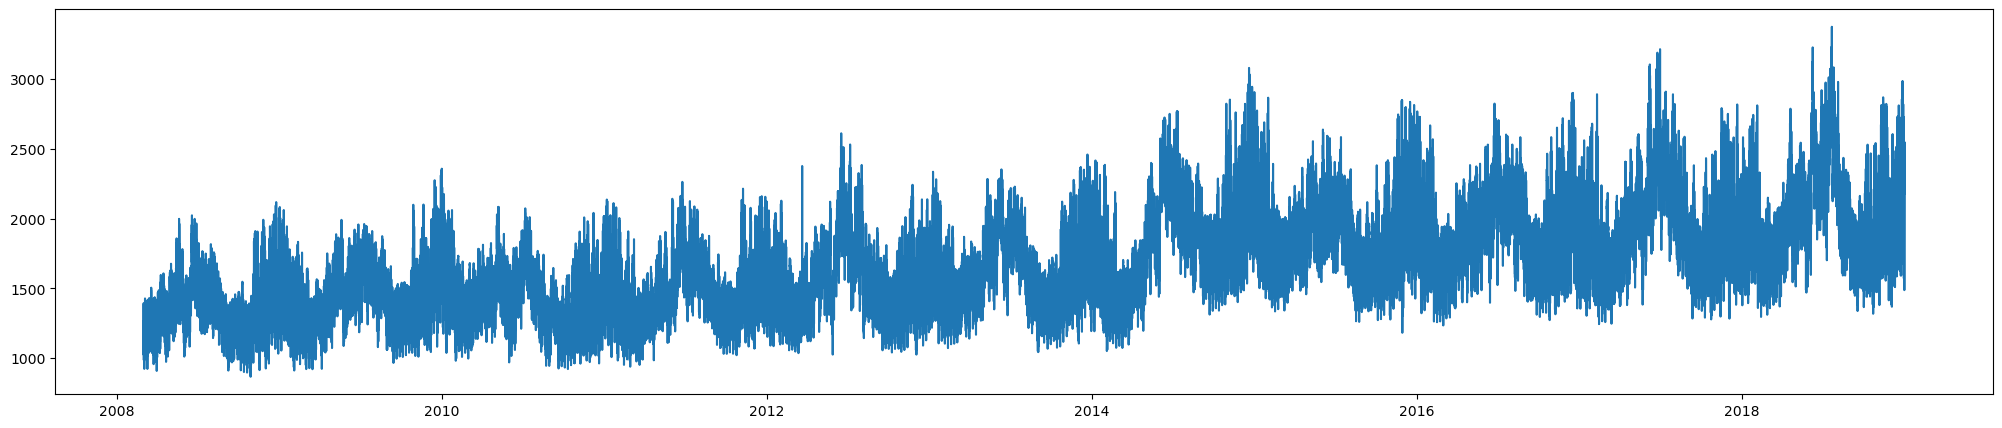

In [13]:
mat.figure(figsize=(25,5))
mat.plot(
    'datetime',
    'energy',
    data=new_train_data
)

In [15]:
new_train_data.describe()

,row_id,datetime,energy
count,93092.000000,93092,93092.000000
mean,47481.704002,2013-07-31 08:42:14.408971520,1702.995014
min,1.000000,2008-03-01 00:00:00,866.388600
25%,23745.750000,2010-11-15 08:45:00,1431.541100
50%,47476.500000,2013-07-31 03:30:00,1654.465800
75%,71221.250000,2016-04-15 12:15:00,1935.993450
max,94992.000000,2018-12-31 23:00:00,3374.399600
std,27423.379383,NaN,369.322103


In [17]:
new_train_data.drop('row_id', axis=1, inplace=True)

In [18]:
new_train_data.describe()

,datetime,energy
count,93092,93092.000000
mean,2013-07-31 08:42:14.408971520,1702.995014
min,2008-03-01 00:00:00,866.388600
25%,2010-11-15 08:45:00,1431.541100
50%,2013-07-31 03:30:00,1654.465800
75%,2016-04-15 12:15:00,1935.993450
max,2018-12-31 23:00:00,3374.399600
std,NaN,369.322103


# datetime

In [19]:
import datetime as dt
new_train_data['datetime'] = new_train_data['datetime'].dt.date

In [20]:
new_train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93092 entries, 0 to 94991
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  93092 non-null  object 
 1   energy    93092 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.1+ MB


In [21]:
new_train_data['datetime'] = pd.to_datetime(new_train_data['datetime'])

In [22]:
new_train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93092 entries, 0 to 94991
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  93092 non-null  datetime64[ns]
 1   energy    93092 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.1 MB


In [23]:
aggregated_data = new_train_data.groupby('datetime').sum()

In [24]:
aggregated_data

,energy
datetime,
2008-03-01,30336.129562
2008-03-02,27611.734500
2008-03-03,25970.325000
2008-03-04,28984.369500
2008-03-05,30669.940500
...,...
2018-12-27,59451.167600
2018-12-28,57156.237600
2018-12-29,53632.752800


In [25]:
aggregated_data.to_csv('m_aggregated_dataset.csv')

In [26]:
#new_train_data.groupby('datetime').head()

In [50]:
indexed_train_data = train_data

In [53]:
indexed_train_data.index = indexed_train_data.datetime

In [54]:
indexed_train_data.drop('datetime', axis=1,inplace=True)

In [55]:
indexed_train_data.head()

,row_id,energy
datetime,,
2008-03-01 00:00:00,1,1259.985563
2008-03-01 01:00:00,2,1095.541500
2008-03-01 02:00:00,3,1056.247500
2008-03-01 03:00:00,4,1034.742000
2008-03-01 04:00:00,5,1026.334500


In [56]:
indexed_train_data.to_csv('m_indexed_dataset.csv')

# seasonal decompose

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_data = seasonal_decompose(
    aggregated_data, 
    model="additive",
    period=(52)
)


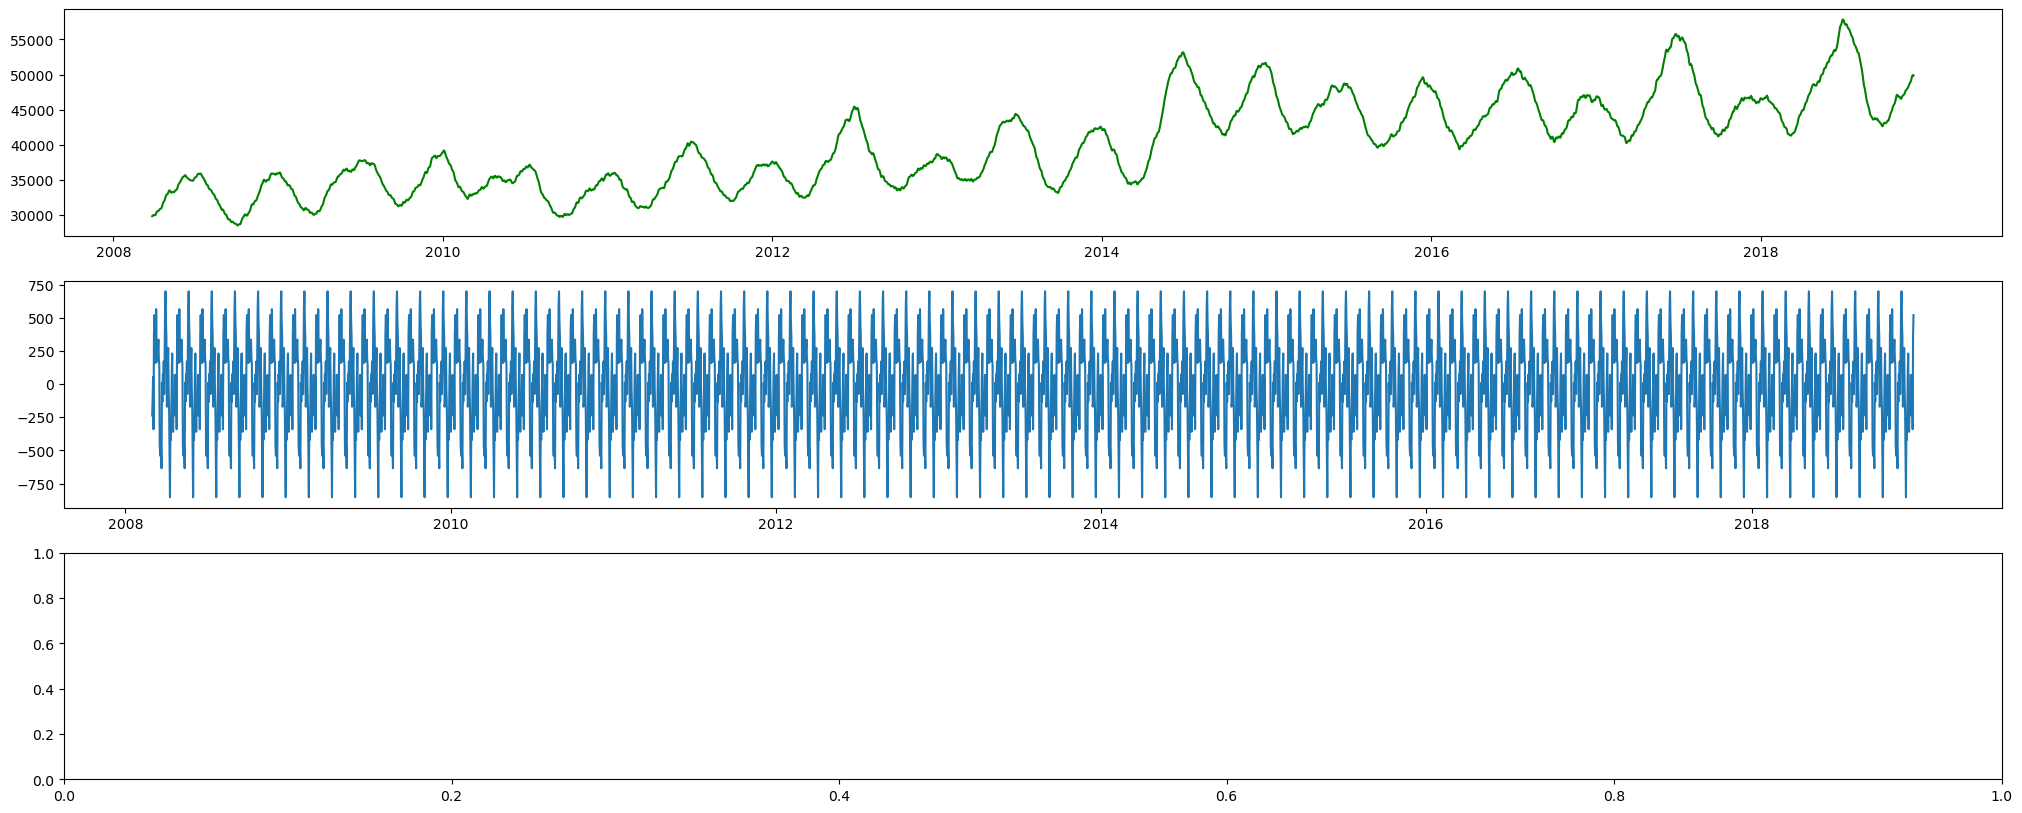

In [26]:
mat.figure(figsize=(25,10))
ax1=mat.subplot(311)
mat.plot(decompose_data.trend.index, decompose_data.trend, color='green')
ax2=mat.subplot(312)
mat.plot(decompose_data.seasonal.index, decompose_data.seasonal)
ax2=mat.subplot(313)

In [27]:
decompose_data.seasonal

datetime
2008-03-01   -236.970628
2008-03-02   -123.031661
2008-03-03     53.997682
2008-03-04   -340.571236
2008-03-05    375.615555
                 ...    
2018-12-27   -123.031661
2018-12-28     53.997682
2018-12-29   -340.571236
2018-12-30    375.615555
2018-12-31    520.729209
Name: seasonal, Length: 3958, dtype: float64

# simple moving average

In [28]:
sma_win = 7
sma = aggregated_data.rolling(window=sma_win).mean()

In [29]:
sma

,energy
datetime,
2008-03-01,NaN
2008-03-02,NaN
2008-03-03,NaN
2008-03-04,NaN
2008-03-05,NaN
...,...
2018-12-27,53596.879600
2018-12-28,54622.607600
2018-12-29,54967.134514


In [30]:
ema_win = 30
ema = aggregated_data.ewm(span=ema_win, adjust=False).mean()

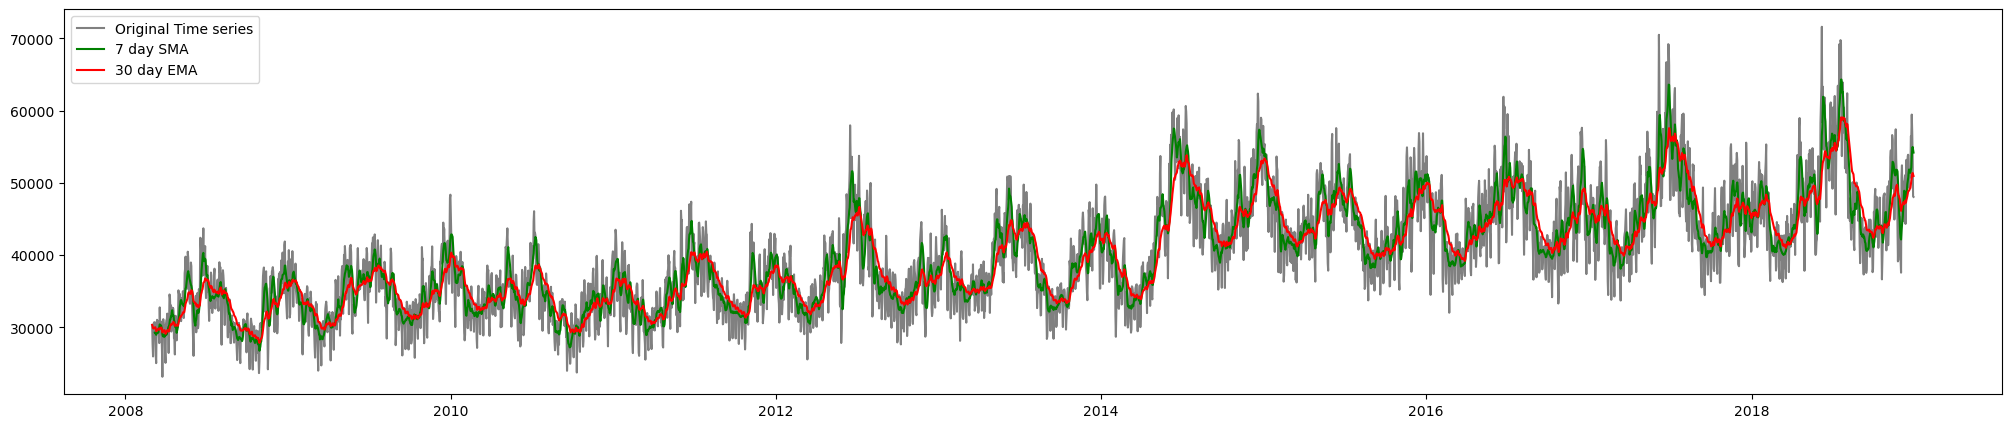

In [31]:
mat.figure(figsize=(25,5))
mat.plot(aggregated_data, 'grey', label='Original Time series')
mat.plot(sma.index ,sma.energy, 'green', label = f'{sma_win} day SMA')
mat.plot(ema.index, ema.energy, 'red', label = f'{ema_win} day EMA')
mat.legend()

# arima

In [1]:
#pip install pmdarima

In [1]:
from pmdarima import auto_arima

In [57]:
stepwise_fit = auto_arima(aggregated_data, seasonal=True, m=12)

MemoryError: Unable to allocate 23.7 MiB for an array with shape (28, 28, 3959) and data type float64

Exception ignored in: 'statsmodels.tsa.statespace._kalman_smoother.dKalmanSmoother.reset_filter_method'
Traceback (most recent call last):
  File "statsmodels\tsa\statespace\_kalman_smoother.pyx", line 982, in statsmodels.tsa.statespace._kalman_smoother.dKalmanSmoother.allocate_arrays
numpy.core._exceptions._ArrayMemoryError: Unable to allocate 23.7 MiB for an array with shape (28, 28, 3959) and data type float64


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\user\AppData\Local\Temp\ipykernel_11124\3779363844.py", line 1, in <module>
    stepwise_fit = auto_arima(aggregated_data, seasonal=True, m=12)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\pmdarima\arima\auto.py", line 701, in auto_arima
    sorted_res = search.solve()
                 ^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\pmdarima\arima\_auto_solvers.py", line 366, in solve
    self._do_fit((p, d, q), (P - 1, D, Q + 1, m)):
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\pmdarima\arima\_auto_solvers.py", line 235, in _do_fit
    fit, fit_time, new_ic = self._fit_arima(
                            ^^^^^^^^^^^^^^^^
  File "C:\U